# 6.1 Polls: Descriptive Analysis

256 nationwide polls (Jul – Nov 2024) from Wikipedia.

**Input:** `Data/1_Bronze/Polls/wikipedia_polls.csv`

<!-- toc -->
## Contents
- [Rolling Average Over Time](#rolling-average-over-time)
- [Margin Over Time](#margin-over-time)
- [Distribution](#distribution)
- [Monthly Averages](#monthly-averages)
- [Pollster Bias](#pollster-bias)
- [Summary](#summary)


In [1]:
import sys, os, re, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from house_style import (
    apply_style, styled_fig, style_ax, add_events, event_legend_handles,
    REPUBLICAN, DEMOCRAT, TEXT_PRIMARY, TEXT_MUTED,
    BG_DARK, BG_PANEL, PALETTE
)
apply_style()

In [2]:
df = pd.read_csv('../../Data/1_Bronze/Polls/wikipedia_polls.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Pollster_clean'] = df['Pollster'].astype(str).apply(lambda s: re.sub(r'\[.*?\]', '', s).strip())

print(f"Polls : {len(df)}  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
df[['Trump', 'Harris', 'Margin']].describe().round(2)

Polls : 256  |  2024-06-24 → 2024-11-04


,Trump,Harris,Margin
count,256.00,256.00,192.00
mean,46.72,47.89,3.07
std,2.41,2.74,1.68
min,37.00,38.00,1.00
25%,45.00,46.78,2.00
50%,47.00,48.00,3.00
75%,48.00,50.00,4.00
max,53.00,53.00,8.00


In [3]:
print(f"Trump leads  : {(df['Trump'] > df['Harris']).sum()} polls")
print(f"Harris leads : {(df['Trump'] < df['Harris']).sum()} polls")
print(f"Tied         : {(df['Trump'] == df['Harris']).sum()} polls")

Trump leads  : 83 polls
Harris leads : 151 polls
Tied         : 22 polls


### Rolling Average Over Time

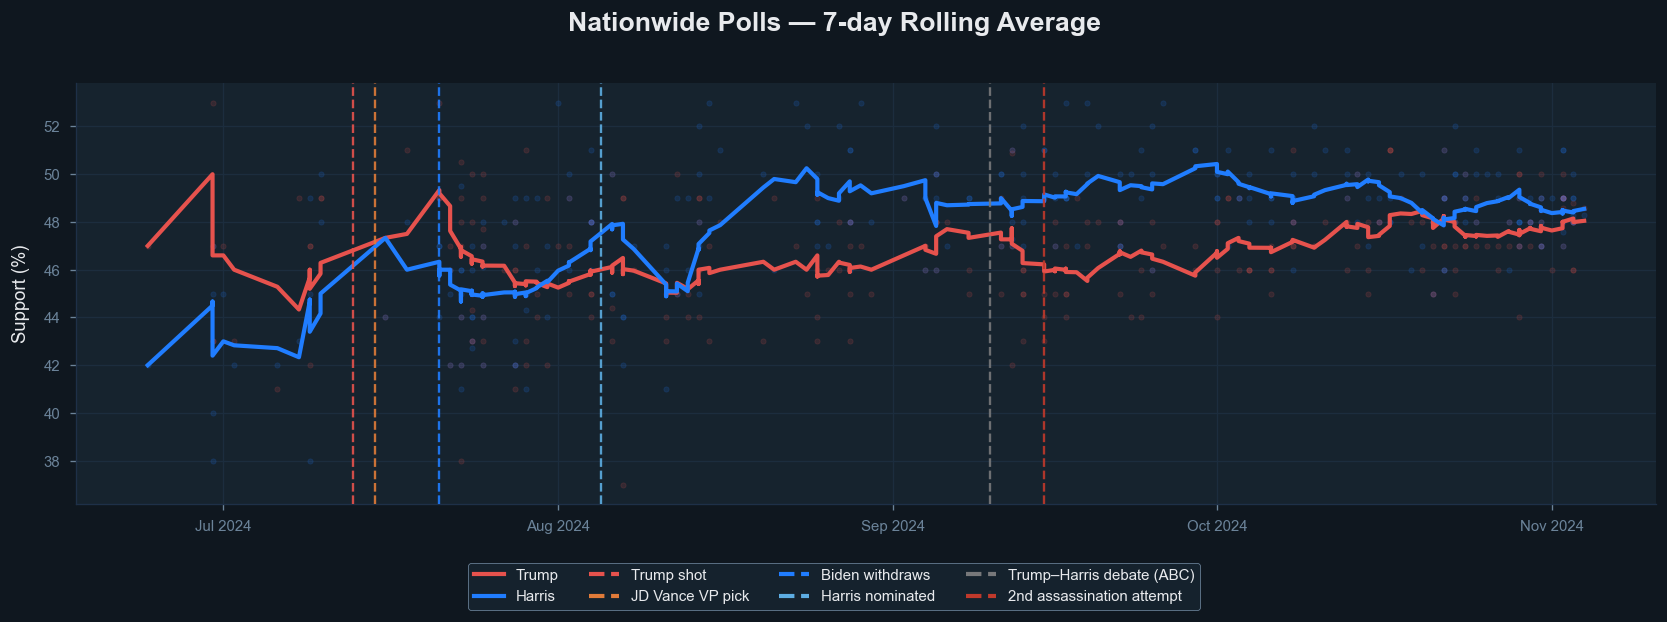

In [4]:
df_plot     = df.dropna(subset=['Trump','Harris']).set_index('Date').sort_index()
trump_roll  = df_plot['Trump'].rolling('7D',  min_periods=1).mean()
harris_roll = df_plot['Harris'].rolling('7D', min_periods=1).mean()

fig, ax = styled_fig(figsize=(14, 5), title='Nationwide Polls — 7-day Rolling Average')

ax.scatter(df_plot.index, df_plot['Trump'],  color=REPUBLICAN, alpha=0.15, s=10, zorder=2)
ax.scatter(df_plot.index, df_plot['Harris'], color=DEMOCRAT,   alpha=0.15, s=10, zorder=2)
ax.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, label='Trump')
ax.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, label='Harris')

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Support (%)', grid_axis='y')

from matplotlib.lines import Line2D
data_h = [Line2D([],[],color=REPUBLICAN,linewidth=2.5,label='Trump'),
          Line2D([],[],color=DEMOCRAT,  linewidth=2.5,label='Harris')]
fig.legend(handles=data_h + event_legend_handles(),
           loc='lower center', bbox_to_anchor=(0.5,0.01),
           ncol=4, facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0,0.12,1,1])
plt.show()

Harris leidt in 151 van de 256 peilingen, Trump in 83. In juni (Biden nog kandidaat) staat Trump nog voor, maar na zijn terugtrekking (21 jul) draait de trend. Vanaf augustus neemt Harris een consistente voorsprong die ze tot aan de verkiezing vasthoudt.

### Margin Over Time

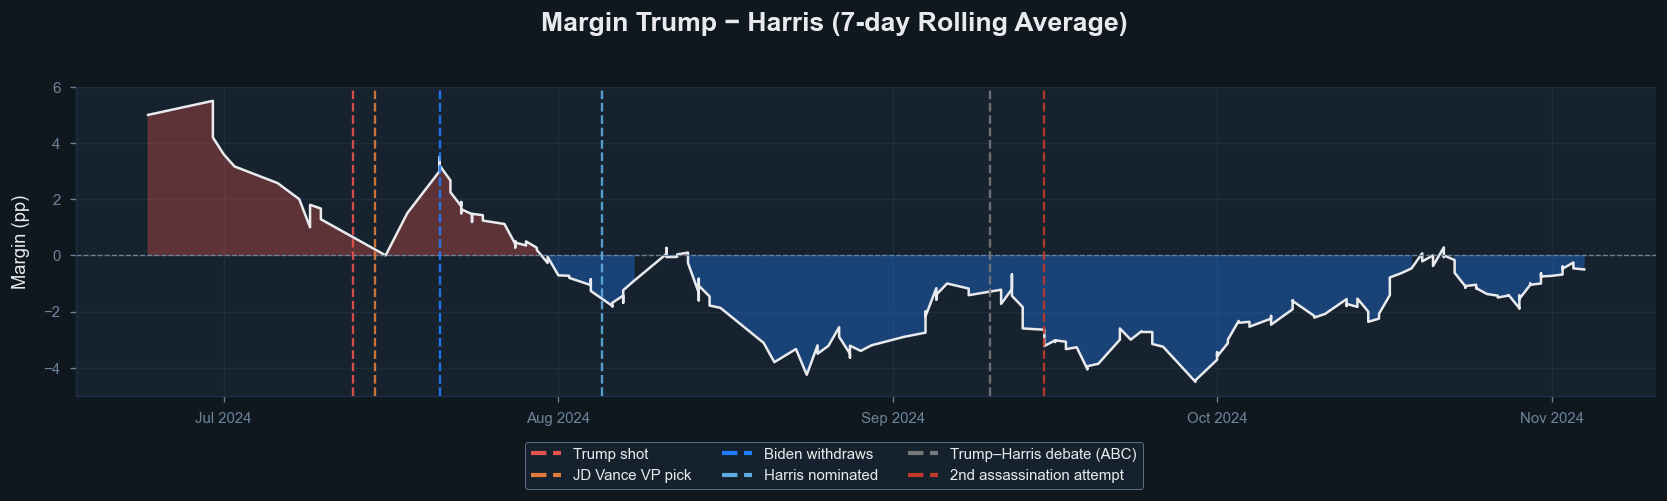

In [5]:
margin_roll = trump_roll - harris_roll

fig, ax = styled_fig(figsize=(14, 4), title='Margin Trump − Harris (7-day Rolling Average)')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll >= 0), color=REPUBLICAN, alpha=0.35, label='Trump leads')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll <  0), color=DEMOCRAT,   alpha=0.35, label='Harris leads')
ax.plot(margin_roll, color=TEXT_PRIMARY, linewidth=1.5)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Margin (pp)', grid_axis='y')
fig.legend(handles=event_legend_handles(),
           loc='lower center', bbox_to_anchor=(0.5,0.01),
           ncol=3, facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0,0.12,1,1])
plt.show()

Trump staat slechts in de eerste weken voor. Vanaf eind juli kantelt de marge naar Harris, die tot november negatief (Harris voorop) blijft. Het verschil schommelt tussen −1 en −3 pp — krap maar consistent.

### Distribution

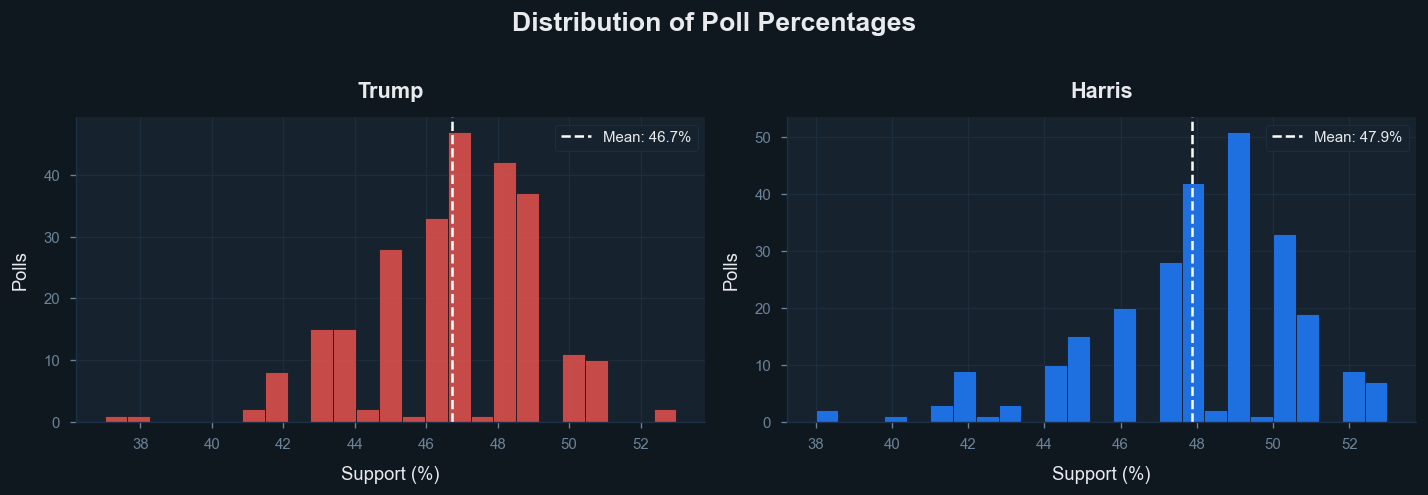

In [6]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(12, 4),
                       title='Distribution of Poll Percentages')
for ax, col, color in zip(axes, ['Trump','Harris'], [REPUBLICAN, DEMOCRAT]):
    data = df[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.85, edgecolor=BG_DARK)
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}%')
    style_ax(ax, xlabel='Support (%)', ylabel='Polls', title=col, grid_axis='y')
    ax.legend()
plt.tight_layout()
plt.show()

Trump clustert rond 46.7%, Harris rond 47.9% — beide normaal verdeeld maar duidelijk gescheiden. De 1.2 pp hogere gemiddelde van Harris weerspiegelt haar structurele pollingvoordeel over de volledige periode.

### Monthly Averages

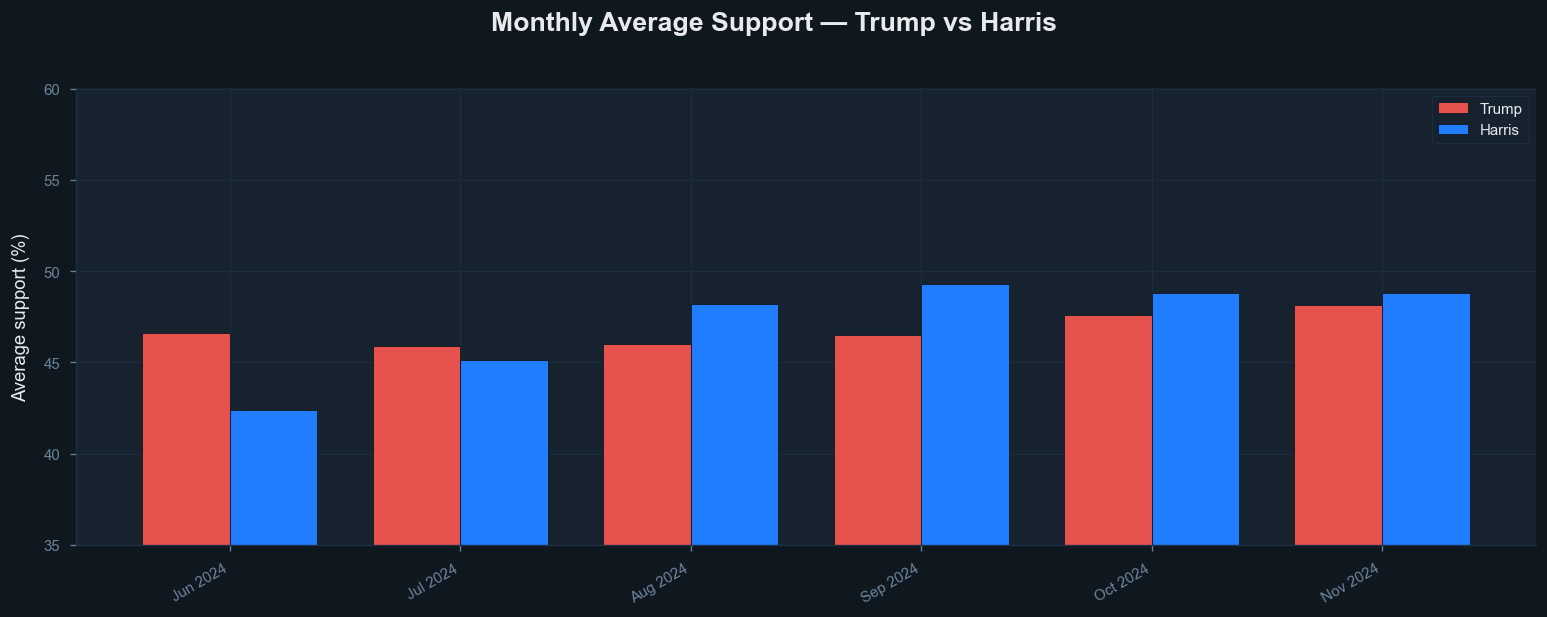

In [7]:
df_monthly = (df.set_index('Date')[['Trump','Harris']]
                .resample('ME').mean().dropna())
labels = df_monthly.index.strftime('%b %Y')
x, w = np.arange(len(labels)), 0.38

fig, ax = styled_fig(figsize=(13, 5), title='Monthly Average Support — Trump vs Harris')
ax.bar(x - w/2, df_monthly['Trump'],  w, color=REPUBLICAN, label='Trump',  edgecolor=BG_DARK)
ax.bar(x + w/2, df_monthly['Harris'], w, color=DEMOCRAT,   label='Harris', edgecolor=BG_DARK)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', color=TEXT_MUTED)
ax.set_ylim(35, 60)
style_ax(ax, ylabel='Average support (%)', grid_axis='y')
ax.legend()
plt.tight_layout()
plt.show()

Trump leidt enkel in juni (46.6% vs 42.4% — Biden nog kandidaat). Vanaf augustus neemt Harris de koppositie over. Haar sterkste maand is september (49.3%), samenvallend met haar nominatie en het ABC-debat. In oktober–november verkleint Trump het gat maar haalt het niet in.

### Pollster Bias

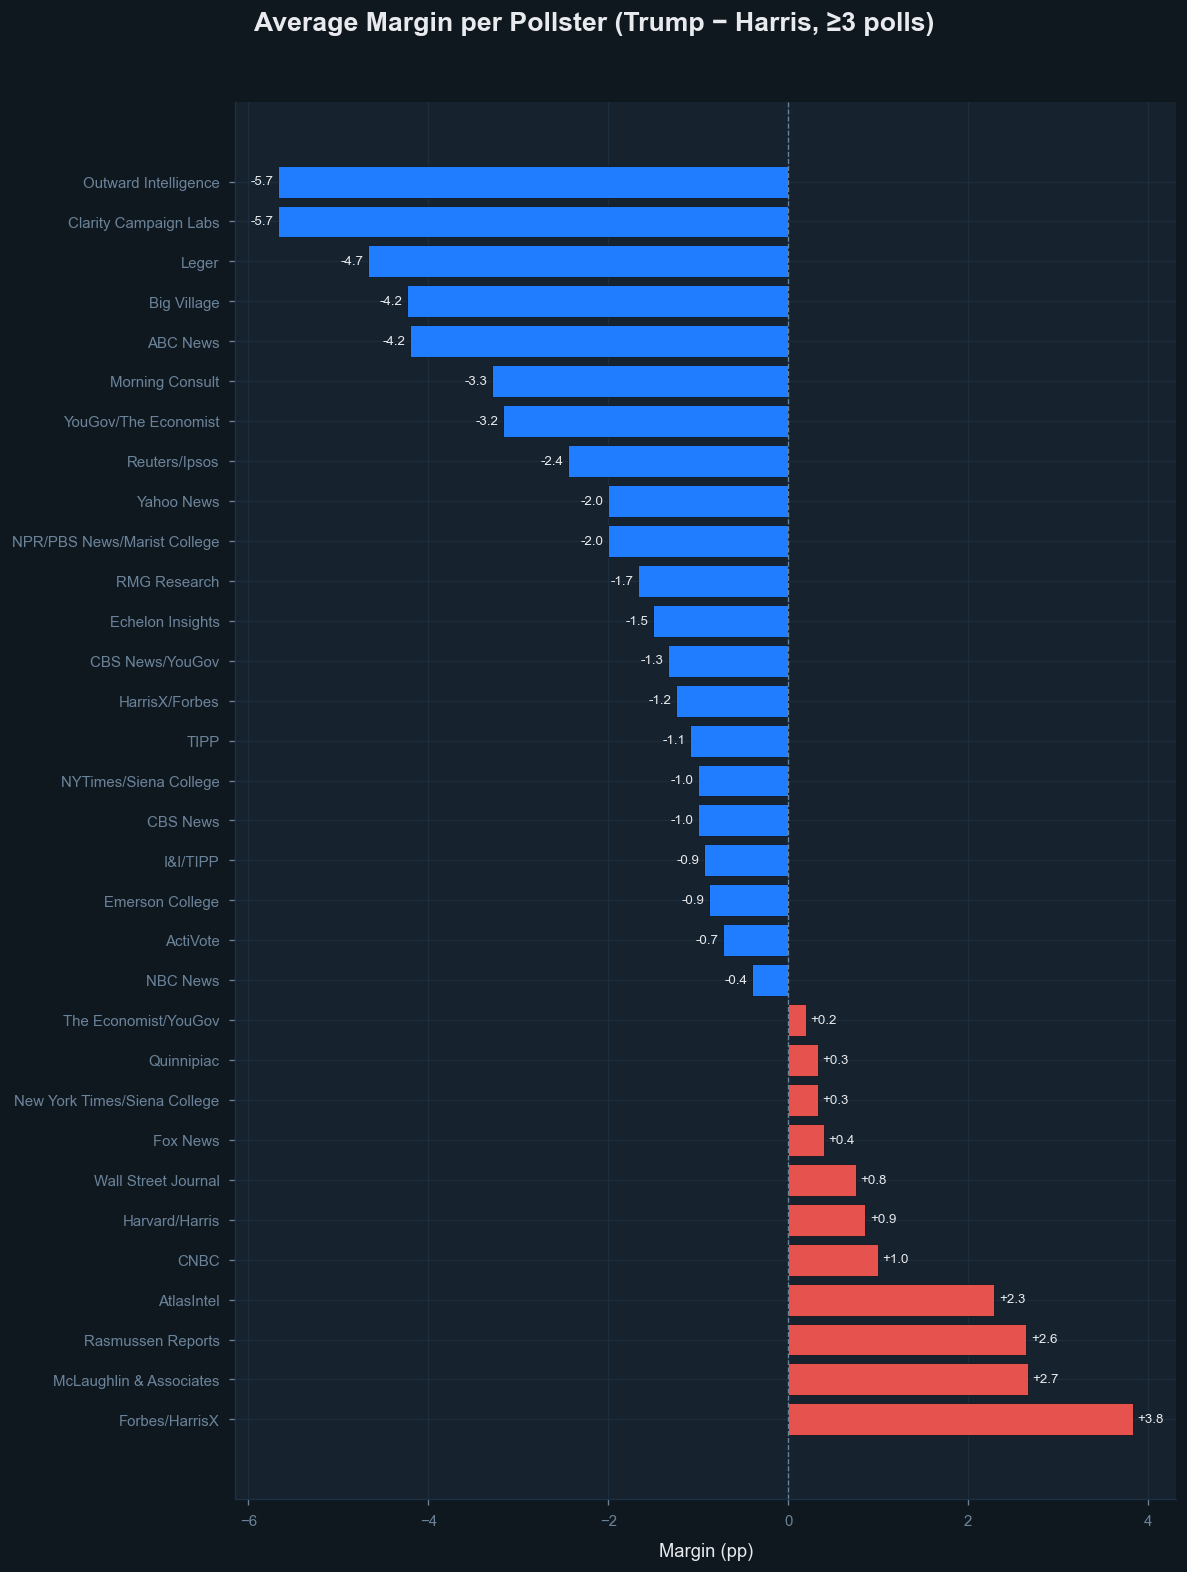

In [8]:
counts = df['Pollster_clean'].value_counts()
top    = counts[counts >= 3].index
stats  = (df[df['Pollster_clean'].isin(top)]
          .groupby('Pollster_clean')[['Trump','Harris']]
          .mean()
          .assign(Margin=lambda x: x['Trump'] - x['Harris'])
          .sort_values('Margin', ascending=False))

colors = [REPUBLICAN if m >= 0 else DEMOCRAT for m in stats['Margin']]
fig, ax = styled_fig(figsize=(10, max(4, len(stats)*0.4)),
                     title='Average Margin per Pollster (Trump − Harris, ≥3 polls)')
bars = ax.barh(stats.index, stats['Margin'], color=colors, edgecolor=BG_DARK)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')
for bar, val in zip(bars, stats['Margin']):
    ax.text(val + (0.05 if val>=0 else -0.05),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', ha=('left' if val>=0 else 'right'),
            color=TEXT_PRIMARY, fontsize=8)
style_ax(ax, xlabel='Margin (pp)', grid_axis='x')
plt.tight_layout()
plt.show()

Duidelijke house effects: Rasmussen, McLaughlin en Forbes/HarrisX geven Trump +2 tot +4 pp; Morning Consult, ABC News en Clarity geven Harris +4 tot +6 pp. De meeste pollsters wijzen Harris als frontrunner aan — aggregatie over pollsters is essentieel om vertekening te corrigeren.

### Summary

In [9]:
df['dir_margin'] = df['Trump'] - df['Harris']
avg_margin = df['dir_margin'].mean()
leader = 'Trump' if avg_margin > 0 else 'Harris'

print(f"Polls          : {len(df)}")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Avg Trump      : {df['Trump'].mean():.1f}%")
print(f"Avg Harris     : {df['Harris'].mean():.1f}%")
print(f"Avg margin     : {avg_margin:+.2f} pp  ({leader} leads)")
print(f"Trump leads    : {(df['Trump'] > df['Harris']).sum()} polls")
print(f"Harris leads   : {(df['Trump'] < df['Harris']).sum()} polls")
print(f"Tied           : {(df['Trump'] == df['Harris']).sum()} polls")

Polls          : 256
Date range     : 2024-06-24 → 2024-11-04
Avg Trump      : 46.7%
Avg Harris     : 47.9%
Avg margin     : -1.16 pp  (Harris leads)
Trump leads    : 83 polls
Harris leads   : 151 polls
Tied           : 22 polls
